# 语言模型和数据集


## 环境配置


In [1]:
import os
import sys
sys.path.insert(0, "..")
from src.utils import (
    read_time_machine, tokenize, Vocab, plot
)
from collections import Counter
import numpy as np
import torch

lines = read_time_machine()
tokens = tokenize(lines, 'word')
# 因为每个文本行不一定是一个句子或一个段落，因此我们把所有文本行拼接到一起
corpus = [token for line in tokens for token in line]
vocab = Vocab(tokens)

/opt/buildtools/Python-3.11.4/lib/python3.11/site-packages/torch_npu/utils/_path_manager.py:66: UserWarning: Permission mismatch: The owner of /opt/buildtools/Python-3.11.4/lib/python3.11/site-packages/torch_npu/lib/libop_plugin_atb.so does not match.
  warnings.warn(f"Permission mismatch: The owner of {path} does not match.")


/opt/buildtools/Python-3.11.4/lib/python3.11/site-packages/torch_npu/__init__.py:324: UserWarning: On the interactive interface, the value of TASK_QUEUE_ENABLE is set to 0 by default.                      Do not set it to 1 to prevent some unknown errors
  warnings.warn("On the interactive interface, the value of TASK_QUEUE_ENABLE is set to 0 by default. \


## 练习8.3.1

**题目：** 假设训练数据集中有$100,000$个单词。一个四元语法需要存储多少个词频和相邻多词频率？

**解答：**

对于$100000$个单词，四元组需要存储每个单词的词频，即$P(W_i), i\in (1,100000)$，总计$100000$个。

计算相邻多词频率时，由于二元组、三元组以及四元组构成的词不同，因此需要将每个元组构成的词进行存储，例如"The War of Worlds"，若想知道$P(\text{The War of Worlds})$的概率，需要知道$P(\text{The}),P(\text{War|The}),P(\text{of|The War}),P(\text{Worlds|The War of})$的概率。

因此对于$100000$个单词，其二相邻频率为
$$(1 \times 10^5)^2$$

三相邻频率为
$$(1 \times 10^5)^3$$

四相邻频率为
$$(1 \times 10^5)^4$$

共需要存储$1 \times 10^{10}+1 \times 10^{15} + 1 \times 10^{20}$个相邻多词频率。



## 练习8.3.2

**题目：** 我们如何对一系列对话建模？

**解答：**

N-Gram语法将文本看作一系列的词序列，假设当前词的出现概率与前$N-1$个词相关，根据出现的频率来估计下一个词出现的概率。因此对于对话建模问题，理论上可以将对话中的每个句子看作一个独立的文本序列，并对每个文本序列计算出对应的词频和N-Gram概率，在预测下一个词时，将前$N-1$个词视作上下文，选择出现概率最高的词作为下一个词。重复上述过程，直到生成整个对话。

但是N-Gram对于长距离的依赖关系并不能处理的很好，因此将对话语句处理为独立文本序列后，还可以采用RNN或LSTM进行建模。



In [2]:
# 读取对话数据
dialogues = [
    "Hi,how are you?",
    "I'm fine, thank you. And you?",
    "I'm good too.",
    "That's great!",
    "Thanks.",
]

# 使用 src.utils.tokenize 进行分词（无需 nltk 等额外依赖）
tokens = []
for dialogue in dialogues:
    tokenized_line = tokenize([dialogue], 'word')
    for line in tokenized_line:
        tokens.extend(line)

# 统计词频（复用环境配置中的 Counter）
word_freq = Counter(tokens)

# 计算 N-gram 频率（纯 Python 实现）
def ngrams(sequence, n):
    """生成 n-gram 元组"""
    for i in range(len(sequence) - n + 1):
        yield tuple(sequence[i:i + n])

n = 3
ngrams_freq = Counter(ngrams(tokens, n))
ngrams_prob = {}
for ngram in ngrams_freq:
    context = ' '.join(ngram[:-1])
    if context not in ngrams_prob:
        ngrams_prob[context] = {}
    ngrams_prob[context][ngram[-1]] = ngrams_freq[ngram] / word_freq.get(context, 1)

# 使用 N-gram 模型生成对话
start = 'Hi,'
dialogue = [start]
for i in range(10):
    context = ' '.join(dialogue[-n+1:])
    if context in ngrams_prob:
        next_word = max(ngrams_prob[context], key=ngrams_prob[context].get)
    else:
        next_word = max(word_freq, key=word_freq.get)
    dialogue.append(next_word)
print(' '.join(dialogue))
# 输出: Hi, you you you you you you you you you you

Hi, you? you? you? you? you? you? you? you? you? you?


## 练习8.3.3

**题目：** 一元语法、二元语法和三元语法的齐普夫定律的指数是不一样的，能设法估计么？

**解答：**

齐普夫定律认为，排名与频率之间存在的负相关的关系。即对于大规模文本，将其中每个词的词频进行统计，并由高到低排序标号，则这些单词的频数$F$和这些单词的序号$R$之间存在一个常数$C$，满足$F \times R=C$。



**方法 A：$F \times R=C$ 法**



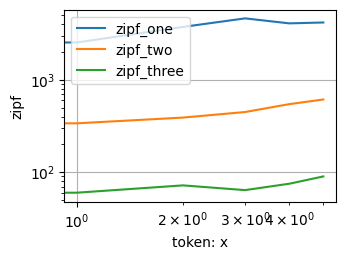

In [3]:
# 复用环境配置中的 corpus、vocab
freqs = [freq for token, freq in vocab.token_freqs]

bigram_tokens = [pair for pair in zip(corpus[:-1], corpus[1:])]
bigram_vocab = Vocab(bigram_tokens)
trigram_tokens = [triple for triple in zip(corpus[:-2], corpus[1:-1], corpus[2:])]
trigram_vocab = Vocab(trigram_tokens)
bigram_freqs = [freq for token, freq in bigram_vocab.token_freqs]
trigram_freqs = [freq for token, freq in trigram_vocab.token_freqs]

# 一元语法的齐普夫定律指数
zipf_one = [freq * (i+1) for i, freq in enumerate(freqs[:6])]

# 二元语法的齐普夫定律指数
zipf_two = [freq * (i+1) for i, freq in enumerate(bigram_freqs[:6])]

# 三元语法的齐普夫定律指数
zip_three = [freq * (i+1) for i, freq in enumerate(trigram_freqs[:6])]

# 绘制图像
plot([zipf_one, zipf_two, zip_three],
     xlabel='token: x', ylabel='zipf',
     xscale='log', yscale='log',
     legend=['zipf_one', 'zipf_two', 'zipf_three'])

**方法 B：最小二乘法拟合**

对于线性方程：$\log n_i = -\alpha \log i + c$，我们可以采用最小二乘法来估计$\alpha$和$c$的值。



In [4]:
# 复用环境配置中的 corpus、vocab
freqs = [freq for token, freq in vocab.token_freqs]

bigram_tokens = [pair for pair in zip(corpus[:-1], corpus[1:])]
bigram_vocab = Vocab(bigram_tokens)
trigram_tokens = [triple for triple in zip(corpus[:-2], corpus[1:-1], corpus[2:])]
trigram_vocab = Vocab(trigram_tokens)
bigram_freqs = [freq for token, freq in bigram_vocab.token_freqs]
trigram_freqs = [freq for token, freq in trigram_vocab.token_freqs]

In [5]:
def estimate_coefficients(x, y):
    # 计算x和y的均值
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    # 计算分子和分母
    numerator = np.sum((x - mean_x) * (y - mean_y))
    denominator = np.sum((x - mean_x)**2)
    
    # 计算斜率a
    a = numerator / denominator
    
    # 计算截距c
    c = mean_y - a * mean_x
    
    return a, c

def compute_zipf(freqs):
    freqs = np.array(freqs)
    index = np.array(range(1, len(freqs) + 1))
    a, c = estimate_coefficients(np.log(index), np.log(freqs))
    return a, c

In [6]:
# 一元语法的齐普夫定律指数
# 注意这里的alpha相当于公式里的负alpha
zipf_one_alpha, zipf_one_const = compute_zipf(freqs)
zipf_one_alpha, zipf_one_const

(-1.0352906770079624, 8.424112526680629)

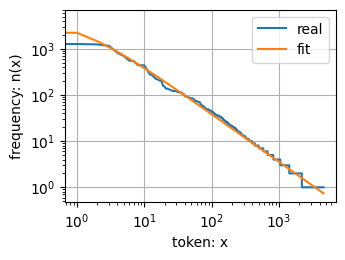

In [7]:
# 验证一元语法的齐普夫定律指数
_freqs = np.exp(zipf_one_alpha * np.log(np.array(range(1, len(freqs) + 1))) + zipf_one_const)
plot([freqs, _freqs], xlabel='token: x',
     ylabel='frequency: n(x)', xscale='log', yscale='log', legend=['real', 'fit'])

In [8]:
# 二元语法的齐普夫定律指数
zipf_two_alpha, zipf_two_const = compute_zipf(bigram_freqs)
zipf_two_alpha, zipf_two_const

(-0.46374303099381303, 4.336273543988693)

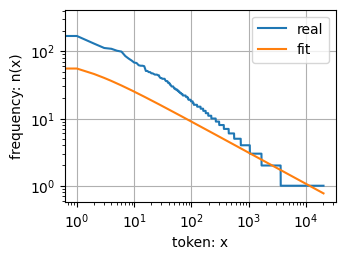

In [9]:
# 验证二元语法的齐普夫定律指数
_bigram_freqs = np.exp(zipf_two_alpha * np.log(np.array(range(1, len(bigram_freqs) + 1))) + zipf_two_const)
plot([bigram_freqs, _bigram_freqs], xlabel='token: x',
     ylabel='frequency: n(x)', xscale='log', yscale='log', legend=['real', 'fit'])

In [10]:
# 三元语法的齐普夫定律指数
zipf_three_alpha, zipf_three_const = compute_zipf(trigram_freqs)
zipf_three_alpha, zipf_three_const

(-0.1641903598331584, 1.5771478160356516)

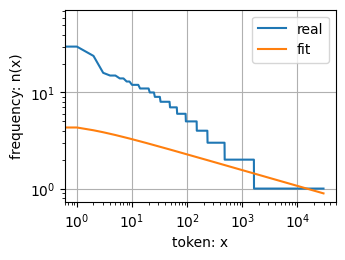

In [11]:
# 验证三元语法的齐普夫定律指数
_trigram_freqs = np.exp(zipf_three_alpha * np.log(np.array(range(1, len(trigram_freqs) + 1))) + zipf_three_const)
plot([trigram_freqs, _trigram_freqs], xlabel='token: x',
     ylabel='frequency: n(x)', xscale='log', yscale='log', legend=['real', 'fit'])

在二元语法和三元语法的情况下计算出的参数拟合效果不好，是因为低频词太多造成的影响。

在二元语法的情况下仅保留前一半的高频词，在三元语法的情况下仅保留前四分之一的高频词，重新计算齐普夫定律指数，拟合效果较好。



In [12]:
# 去掉后一半的低频词，重新计算二元语法的齐普夫定律指数
fit_count = len(bigram_freqs) // 2
zipf_two_alpha, zipf_two_const = compute_zipf(bigram_freqs[:fit_count])
zipf_two_alpha, zipf_two_const

(-0.6484052265835802, 5.735152847309713)

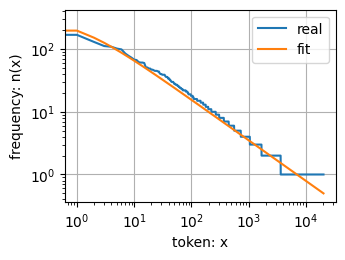

In [13]:
# 验证重新计算的二元语法的齐普夫定律指数
_bigram_freqs = np.exp(zipf_two_alpha * np.log(np.array(range(1, len(bigram_freqs) + 1))) + zipf_two_const)
plot([bigram_freqs, _bigram_freqs], xlabel='token: x',
     ylabel='frequency: n(x)', xscale='log', yscale='log', legend=['real', 'fit'])

In [14]:
# 去掉后四分之三的低频词，重新计算三元语法的齐普夫定律指数
fit_count = len(trigram_freqs) // 4
zipf_three_alpha, zipf_three_const = compute_zipf(trigram_freqs[:fit_count])
zipf_three_alpha, zipf_three_const

(-0.3844605357038146, 3.241983568494706)

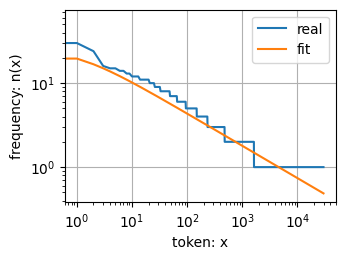

In [15]:
# 验证重新计算的三元语法的齐普夫定律指数
_trigram_freqs = np.exp(zipf_three_alpha * np.log(np.array(range(1, len(trigram_freqs) + 1))) + zipf_three_const)
plot([trigram_freqs, _trigram_freqs], xlabel='token: x',
     ylabel='frequency: n(x)', xscale='log', yscale='log', legend=['real', 'fit'])

## 练习8.3.4

**题目：** 想一想读取长序列数据的其他方法？

**解答：**

在读取长序列数据时，除了随机采样和顺序分区，还可以采用下列方法：
- 滑动窗口：通过滑动窗口，可以将一个长序列拆分为若干等长的有重叠子序列，在BERT中，这些子序列会被当做单独的文本进行处理，然后将所有子序列的输出结果进行整合，获得最终的长文本序列处理结果。
- 分层采样：将整个长序列先拆分为不同层次，使得每个层次包含不同的序列信息，通过这种方法，既可以保留长序列中的上下文信息，也可对整个长序列进行多层次的抽象概括。



## 练习8.3.5

**题目：** 考虑一下我们用于读取长序列的随机偏移量。 1. 为什么随机偏移量是个好主意？ 1. 它真的会在文档的序列上实现完美的均匀分布吗？ 1. 要怎么做才能使分布更均匀？

**解答：**

**1. 为什么随机偏移量是个好主意？**

书中介绍到：
> 由于序列数据本质上是连续的，因此我们在处理数据时需要解决这个问题。 在8.1节中我们以一种相当特别的方式做到了这一点： 当序列变得太长而不能被模型一次性全部处理时， 我们可能希望拆分这样的序列方便模型读取。
> 由于文本序列可以是任意长的， 例如整本《时光机器》（The Time Machine）， 于是任意长的序列可以被我们划分为具有相同时间步数的子序列。 当训练我们的神经网络时，这样的小批量子序列将被输入到模型中。

因此在划分序列时，需要设置一个偏移量，从偏移量的位置开始划分序列。

如果固定偏移量，则会导致迭代后，每次迭代所获取到的子序列均只覆盖有限的序列范围，无法保证全部序列的覆盖性。



In [16]:
my_seq = list(range(35))

def seq_data_iter(corpus, batch_size, num_steps):
    """使用固定偏移量生成一个小批量子序列"""
    # 减去1，是因为我们需要考虑标签
    num_subseqs = (len(corpus) - 1) // num_steps
    # 长度为num_steps的子序列的起始索引
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))

    def data(pos):
        # 返回从pos位置开始的长度为num_steps的序列
        return corpus[pos: pos + num_steps]

    num_batches = num_subseqs // batch_size
    for i in range(0, batch_size * num_batches, batch_size):
        # 在这里，initial_indices包含子序列的起始索引
        initial_indices_per_batch = initial_indices[i: i + batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j + 1) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)

for i in range(3):  # 演示3次迭代，每次都输出完全相同的序列
    print(f'i={i}')
    for X, Y in seq_data_iter(my_seq, batch_size=2, num_steps=5):
        print('X: ', X, '\nY:', Y)
# 输出：每次迭代输出的X和Y完全相同
# i=0: X=[[0,1,2,3,4],[5,6,7,8,9]] Y=[[1,2,3,4,5],[6,7,8,9,10]]
#      X=[[10,11,12,13,14],[15,16,17,18,19]] Y=[[11,12,13,14,15],[16,17,18,19,20]]
#      X=[[20,21,22,23,24],[25,26,27,28,29]] Y=[[21,22,23,24,25],[26,27,28,29,30]]
# i=1: （与i=0完全相同）
# i=2: （与i=0完全相同）


i=0
X:  tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]]) 
Y: tensor([[ 1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10]])
X:  tensor([[10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]]) 
Y: tensor([[11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20]])
X:  tensor([[20, 21, 22, 23, 24],
        [25, 26, 27, 28, 29]]) 
Y: tensor([[21, 22, 23, 24, 25],
        [26, 27, 28, 29, 30]])
i=1
X:  tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]]) 
Y: tensor([[ 1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10]])
X:  tensor([[10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]]) 
Y: tensor([[11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20]])
X:  tensor([[20, 21, 22, 23, 24],
        [25, 26, 27, 28, 29]]) 
Y: tensor([[21, 22, 23, 24, 25],
        [26, 27, 28, 29, 30]])
i=2
X:  tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]]) 
Y: tensor([[ 1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10]])
X:  tensor([[10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]]) 
Y: tensor([[11, 12, 13, 14, 15],
        [

加入随机偏移量后，每次迭代时从不同初始位置获取的子序列，既保证了覆盖性，也保证了随机性。



In [17]:
import random

def seq_data_iter_random(corpus, batch_size, num_steps):
    """使用随机抽样生成一个小批量子序列"""
    # 从随机偏移量开始对序列进行分区，随机范围包括num_steps-1
    corpus = corpus[random.randint(0, num_steps - 1):]
    # 减去1，是因为我们需要考虑标签
    num_subseqs = (len(corpus) - 1) // num_steps
    # 长度为num_steps的子序列的起始索引
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    # 在随机抽样的迭代过程中，
    # 来自两个相邻的、随机的、小批量中的子序列不一定在原始序列上相邻
    random.shuffle(initial_indices)

    def data(pos):
        # 返回从pos位置开始的长度为num_steps的序列
        return corpus[pos: pos + num_steps]

    num_batches = num_subseqs // batch_size
    for i in range(0, batch_size * num_batches, batch_size):
        # 在这里，initial_indices包含子序列的随机起始索引
        initial_indices_per_batch = initial_indices[i: i + batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j + 1) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)

for i in range(3):  # 演示3次迭代，每次输出的序列各不相同
    print(f'i={i}')
    for X, Y in seq_data_iter_random(my_seq, batch_size=2, num_steps=5):
        print('X: ', X, '\nY:', Y)
# 输出：每次迭代的序列各不相同，体现了随机性
# 例如 i=0: X=[[5,6,7,8,9],[19,20,21,22,23]], [[10,11,12,13,14],[24,25,26,27,28]]
#      i=1: X=[[0,1,2,3,4],[17,18,19,20,21]], [[5,6,7,8,9],[22,23,24,25,26]], [[10,11,12,13,14],[27,28,29,30,31]]
#      i=2: （与i=1不同的排列）


i=0
X:  tensor([[ 7,  8,  9, 10, 11],
        [27, 28, 29, 30, 31]]) 
Y: tensor([[ 8,  9, 10, 11, 12],
        [28, 29, 30, 31, 32]])
X:  tensor([[17, 18, 19, 20, 21],
        [22, 23, 24, 25, 26]]) 
Y: tensor([[18, 19, 20, 21, 22],
        [23, 24, 25, 26, 27]])
X:  tensor([[12, 13, 14, 15, 16],
        [ 2,  3,  4,  5,  6]]) 
Y: tensor([[13, 14, 15, 16, 17],
        [ 3,  4,  5,  6,  7]])
i=1
X:  tensor([[ 2,  3,  4,  5,  6],
        [ 7,  8,  9, 10, 11]]) 
Y: tensor([[ 3,  4,  5,  6,  7],
        [ 8,  9, 10, 11, 12]])
X:  tensor([[12, 13, 14, 15, 16],
        [22, 23, 24, 25, 26]]) 
Y: tensor([[13, 14, 15, 16, 17],
        [23, 24, 25, 26, 27]])
X:  tensor([[27, 28, 29, 30, 31],
        [17, 18, 19, 20, 21]]) 
Y: tensor([[28, 29, 30, 31, 32],
        [18, 19, 20, 21, 22]])
i=2
X:  tensor([[18, 19, 20, 21, 22],
        [ 3,  4,  5,  6,  7]]) 
Y: tensor([[19, 20, 21, 22, 23],
        [ 4,  5,  6,  7,  8]])
X:  tensor([[ 8,  9, 10, 11, 12],
        [13, 14, 15, 16, 17]]) 
Y: tensor([[

**2. 它真的会在文档的序列上实现完美的均匀分布吗？**

长序列采样时，通过为每个采样点加入随机偏移量可以在一定程度上增加子序列的覆盖性和随机性，但是并不能实现完美的均匀分布，因为加入偏移量后无法保证每个采样点的采样概率完全相等，偏移量的存在可能会使得某些子序列被频繁采样，某些子序列被跳过。

**3. 要怎么做才能使分布更均匀？**

一方面，可以采用多次采样后取均值的方法来缓解随机偏移量带来的采样偏差问题。另一方面，也可以降低随机偏移量的大小，使得采样点间的距离更加均匀，以此来提高采样均匀性。



## 练习8.3.6

**题目：** 如果我们希望一个序列样本是一个完整的句子，那么这在小批量抽样中会带来怎样的问题？如何解决？

**解答：**

采用小批量采样时，通常会在序列中随机选取采样点位置，从而导致整个句子的完整性被破坏，并且这种切断方式还会破坏句子间的上下文关系，使得模型无法理解句子结构。

解决这种问题，需要采取措施避免句子序列被截断，以及上下文关系被破坏。例如可以采取手动控制采样位置的方式，确定句子边界后，将边界处设置为采样点。或者增加序列长度，确保长句不会被切断，保留更多的完整句子。



---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)

